# Run Material Aware Flare With Additional Irradiance Regularization

- Normal regularization: 0.01 (default)
- Albedo regularization: 0.01 (default)
- Roughness regularization: 0.01 (default)
- Irradiance regularizatiob: 0.01

In [2]:
import torch
from pathlib import Path

from scripts.material_aware_training import material_aware_training
from scripts.config import PathConfig, MaterialAwareTrainingConfig
from flare.dataset import DatasetLoader
from scripts.flare_inference import build_flare_pipeline, run_inference, visualize_image_batch, visualize_image_buffers, visualize_training_losses, run_relight

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


/home/jsickert/miniconda3/envs/flare/lib/python3.9/site-packages/torch/utils/cpp_extension.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging  # type: ignore[attr-defined]


In [4]:
working_dir = "/home/jsickert/adl4cv"
run_name = "irradiance_regularization"
input_dir = "DATA/001"
train_dir = ["MVI_1814", "MVI_1810"]
output_dir = "out"
flame_path = "/home/jsickert/adl4cv/adl4cv_ws25-26_Relightable-Avatars/flare/flame/FLAME2020/generic_model.pkl"
diffusion_dir = Path("/home/jsickert/adl4cv/flare_diffusion_channels/rgbx/001")
ghostbone = True
batch_size = 2
eval_dir = ["MVI_1812"]

In [5]:
path_config = PathConfig(
    _working_dir=working_dir,
    run_name=run_name,
    input_dir=input_dir,
    output_dir=output_dir,
    flame_path=flame_path,
    diffusion_dir=diffusion_dir,
    train_dir=train_dir,
    eval_dir=eval_dir,
)

training_config1 = MaterialAwareTrainingConfig.default_stage_1_config(batch_size=batch_size, ghostbone=ghostbone)
training_config2 = MaterialAwareTrainingConfig.default_stage_2_config(batch_size=batch_size, ghostbone=ghostbone)

training_config1.weight_diffusion_irradiance_regularization = 0.01
training_config2.weight_diffusion_irradiance_regularization = 0.01

In [4]:
dataset_train = DatasetLoader(path_config, train_dir=path_config.train_dir, sample_ratio=1, pre_load=True)
dataset_val = DatasetLoader(path_config, train_dir=path_config.eval_dir, sample_ratio=1, pre_load=False)

dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=2, collate_fn=dataset_train.collate, shuffle=True, drop_last=True)
dataloader_val = torch.utils.data.DataLoader(dataset_val, batch_size=4, collate_fn=dataset_val.collate, shuffle=True, drop_last=True)

loaded 2903 views


## Run Training

In [6]:
diffusion_normal_losses, diffusion_albedo_losses, diffusion_roughness_losses, diffusion_irradiance_losses = material_aware_training(
    path_config=path_config,
    args1=training_config1,
    args2=training_config2,
    dataset_train=dataset_train,
    dataloader_train=dataloader_train,
)

creating the FLAME Decoder
Rasterizing: ['mask', 'position', 'normal', 'canonical_position']
Training Deformer
STAGE 1: Using positional encoding (NeRF) for intrinsic materials
{'material_mlp_ch': 5, 'light_mlp_ch': 3, 'material_mlp_dims': [128, 128, 128, 128], 'light_mlp_dims': [64, 64]}
{'mask': 2.0, 'normal': 0.1, 'laplacian': 60.0, 'shading': 1.0, 'perceptual_loss': 0.1, 'albedo_regularization': 0.01, 'roughness_regularization': 0.01, 'white_light_regularization': 0.01, 'fresnel_coeff': 0.01, 'diffusion_normal': 0.01, 'diffusion_albedo': 0.01, 'diffusion_roughness': 0.01, 'diffusion_irradiance': 0.01, 'flame_regularization': 1.0}
Batch Size: 2


Epoch 0, Iter 1:   0%|          | 0/2 [00:00<?, ?it/s]Using /home/jsickert/.cache/torch_extensions/py39_cu116 as PyTorch extensions root...
Detected CUDA files, patching ldflags
Emitting ninja build file /home/jsickert/.cache/torch_extensions/py39_cu116/renderutils_plugin/build.ninja...
Building extension module renderutils_plugin...
Allowing ninja to set a default number of workers... (overridable by setting the environment variable MAX_JOBS=N)


ninja: no work to do.


Loading extension module renderutils_plugin...
Epoch 0, Iter 101:   0%|          | 0/2 [00:39<?, ?it/s, loss=0.488]

Decaying flame regularization


...

Decaying diffusion normal regularization


Epoch 0, Iter 1001:   0%|          | 0/1 [04:42<?, ?it/s, loss=0.12] 

Decaying diffusion normal regularization


Epoch 0, Iter 1451: 100%|██████████| 1/1 [06:49<00:00, 409.78s/it, loss=0.0909]

TIME TAKEN (mins): 6


## Evaluate Diffusion Regularization Losses

In [6]:
import json

with open(path_config.experiment_dir / "diffusion_regularization_losses.json", "r") as file:
    diffusion_regularization_losses = json.load(file)

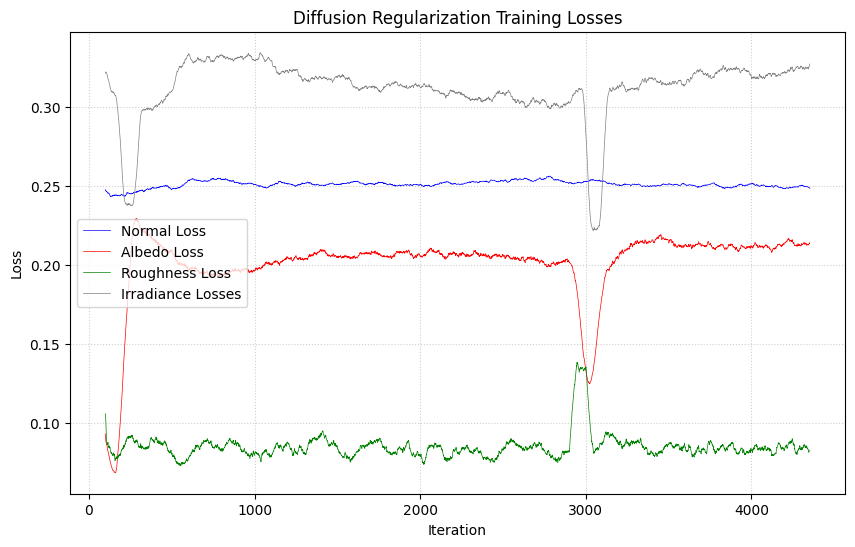

In [8]:
visualize_training_losses(**diffusion_regularization_losses, smoothing_window=100)

## Visualize Inference Outputs

In [11]:
mesh, FLAMEServer, deformer_net, shader, renderer, channels_gbuffer, lgt = build_flare_pipeline(
    dataset_val=dataset_val,
    flame_path=flame_path,
    mesh_path=path_config.experiment_dir / "stage_2/meshes/mesh_latest.obj",
    deformer_path=path_config.experiment_dir / "stage_2/network_weights/deformer_latest.pt",
    shader_path=path_config.experiment_dir / "stage_2/network_weights/shader_latest.pt",
    train_dir=train_dir,
)

creating the FLAME Decoder
STAGE 2: Using hashgrid (tinycudann) for intrinsic materials
{'material_mlp_ch': 5, 'light_mlp_ch': 3, 'material_mlp_dims': [64, 64], 'light_mlp_dims': [64, 64]}


In [13]:
for views in dataloader_val:
    break

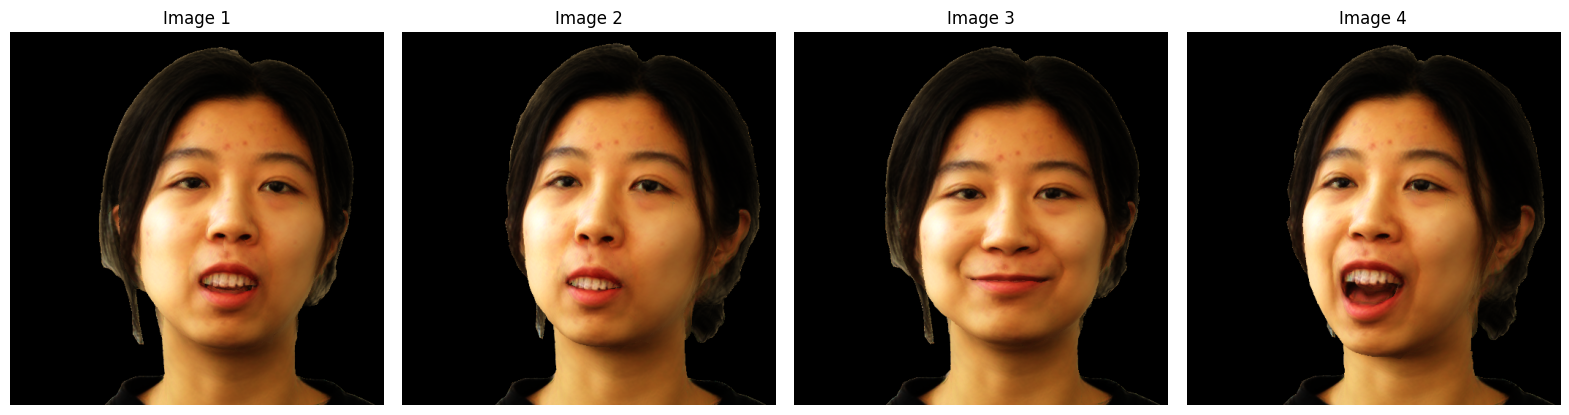

In [14]:
rgb_pred, gbuffers, cbuffers = run_inference(views, mesh, FLAMEServer, deformer_net, shader, renderer, channels_gbuffer, lgt)
visualize_image_batch(rgb_pred)

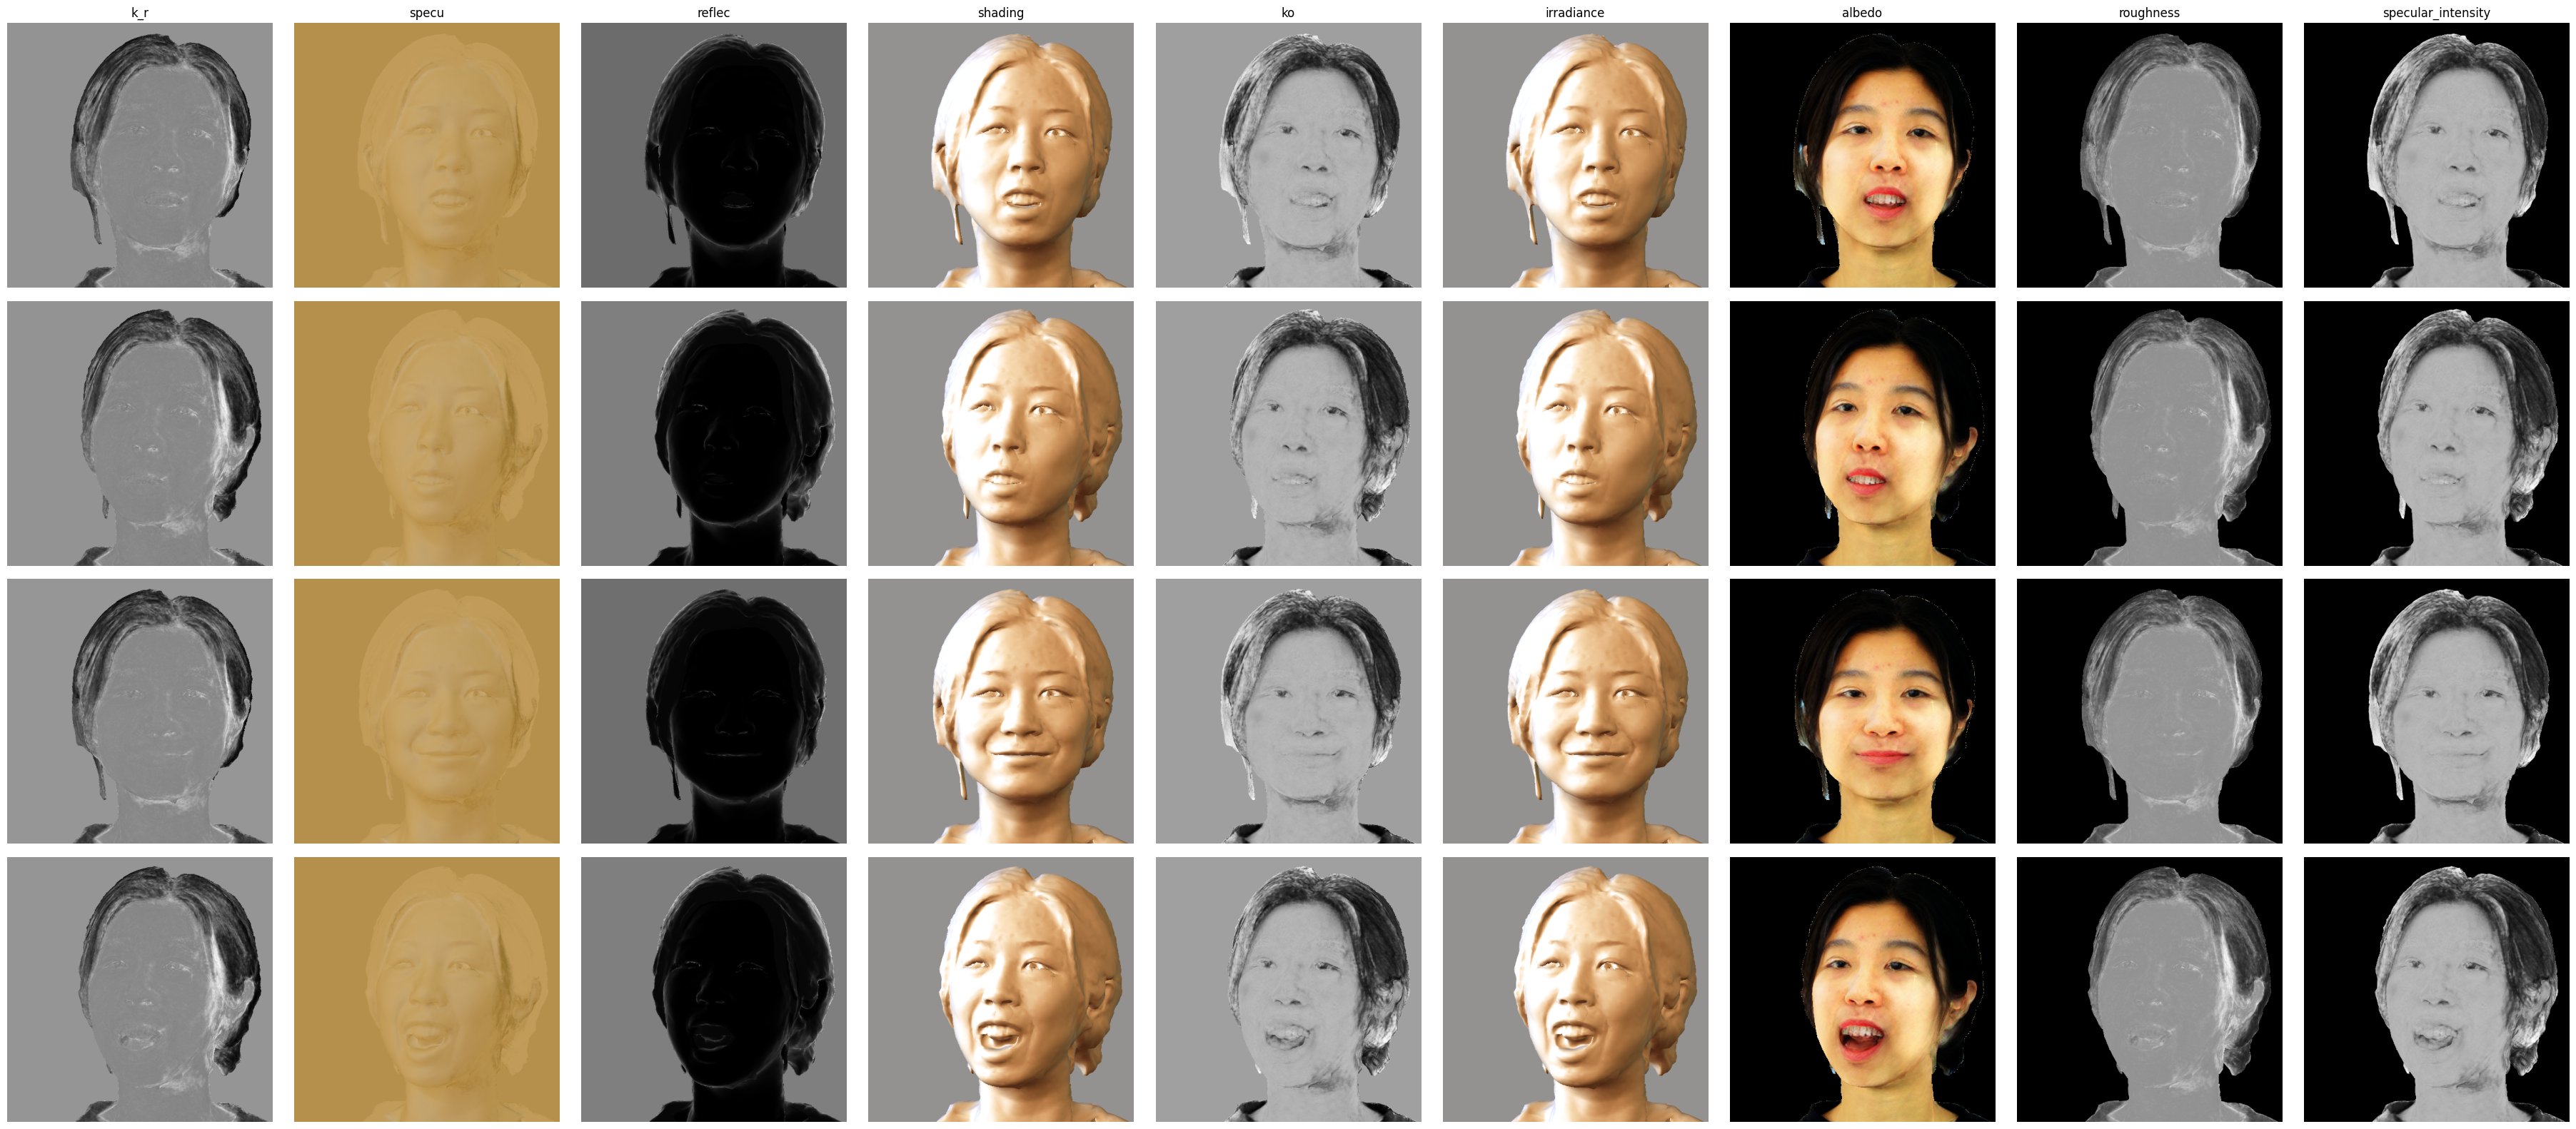

In [16]:
visualize_image_buffers(cbuffers)

## Visualize Religthing

In [21]:
from nvdiffrec.render import light

lgt_list = light.load_target_cubemaps(Path("/home/jsickert/adl4cv/adl4cv_ws25-26_Relightable-Avatars/flare/"))

loading the following environment maps:
/home/jsickert/adl4cv/adl4cv_ws25-26_Relightable-Avatars/flare/assets/env_maps/arboretum_1k.hdr
/home/jsickert/adl4cv/adl4cv_ws25-26_Relightable-Avatars/flare/assets/env_maps/solitude_night_1k.hdr
/home/jsickert/adl4cv/adl4cv_ws25-26_Relightable-Avatars/flare/assets/env_maps/the_sky_is_on_fire_1k.hdr
/home/jsickert/adl4cv/adl4cv_ws25-26_Relightable-Avatars/flare/assets/env_maps/shanghai_bund_1k.hdr


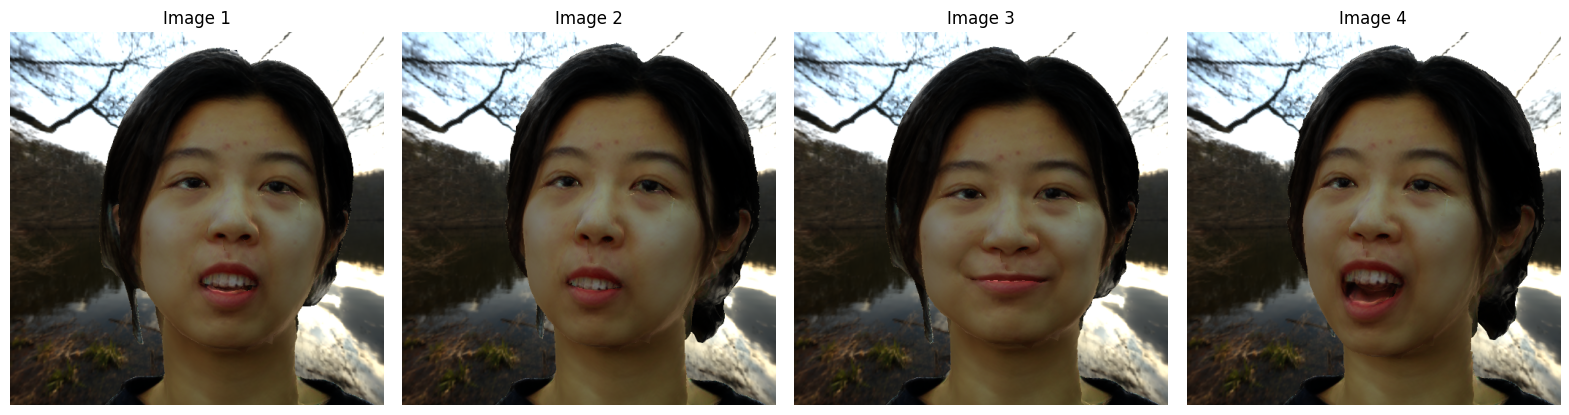

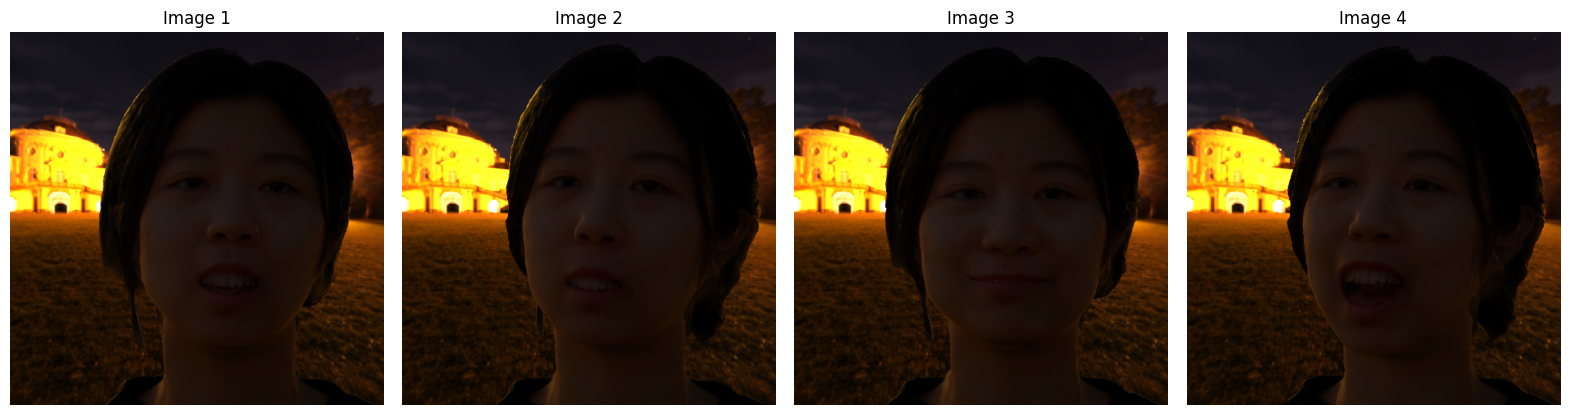

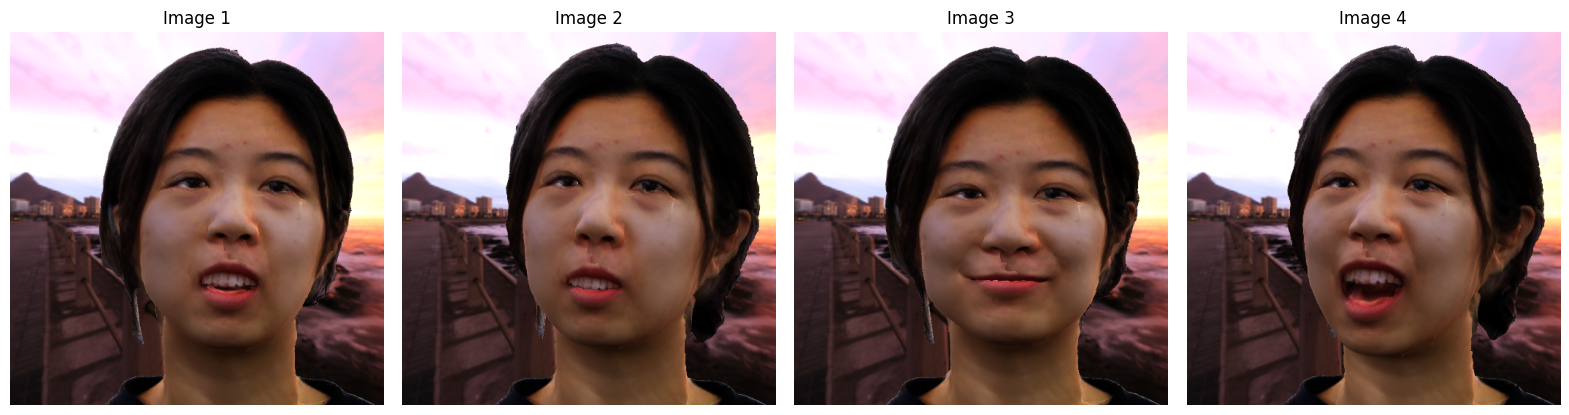

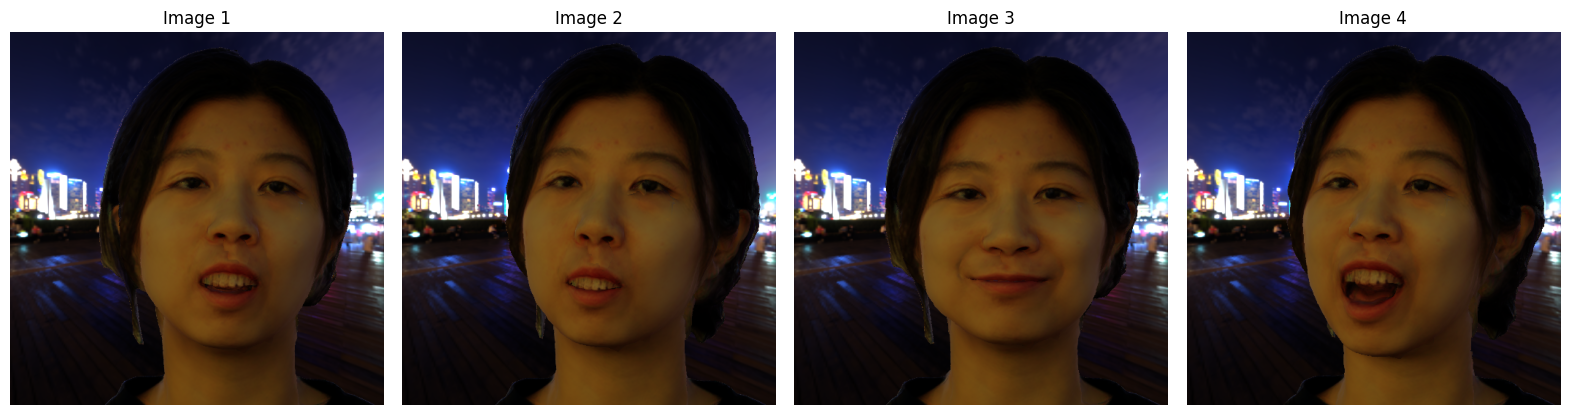

In [22]:
relit_imgs, cbuffers, gbuffer_mask = run_relight(views, mesh, FLAMEServer, deformer_net, shader, renderer, channels_gbuffer, lgt_list)

for relit_img in relit_imgs:
    visualize_image_batch(relit_img.detach())